In [1]:
using Pkg
Pkg.activate("")

using GLMakie, NPZ, FFTW, DeconvMultiStep

  Activating project at `~/radio-imaging/notebooks_and_pyscripts`


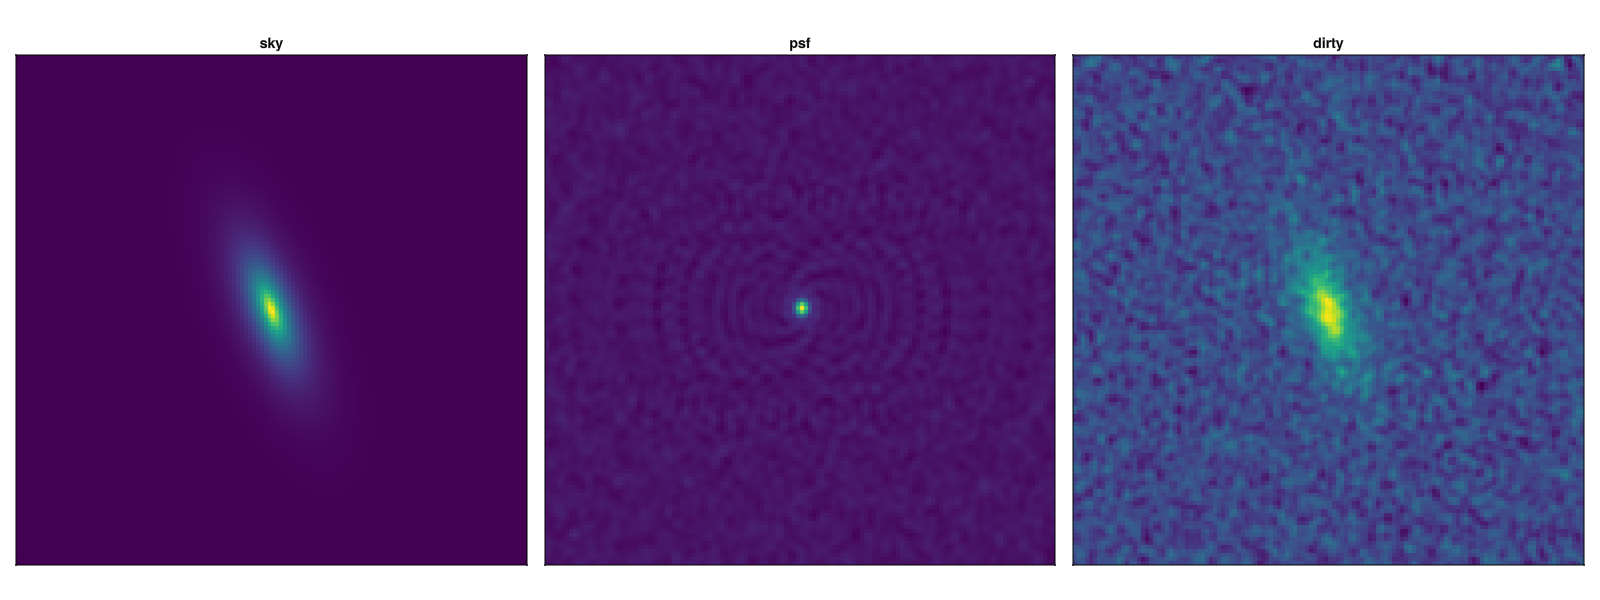

In [2]:
num_sky = 2
psf = npzread("psf.npy")
sky = npzread("true.npy")[num_sky,:,:]
dirty_low = npzread("dirty_low_noise.npy")[num_sky,:,:]
dirty_high = npzread("dirty_proper_noise.npy")[num_sky,:,:]

fig = Figure(; size = (1600, 600))
ax1 = Axis(fig[1, 1], title="sky", aspect=DataAspect())
ax2 = Axis(fig[1, 2], title="psf", aspect=DataAspect())
ax3 = Axis(fig[1, 3], title="dirty", aspect=DataAspect())
heatmap!(ax1, sky)
heatmap!(ax2, psf)
heatmap!(ax3, dirty_low)

hidedecorations!(ax1)
hidedecorations!(ax2)
hidedecorations!(ax3)
fig

Wiener filter for $i=h\ast x+e$ is $w$ such that its Fourier transform equals
$$
W_k = \frac{H_k^\ast}{|H_k|^2 + \frac{S^e_k}{S^x_k}}
$$

- $S^x_k$ and $S^e_k$ PSD of $x$ and $e$ at frequency $k$
- $H_k$ Fourier transform of $h$ at frequency $k$

We consider:
- First $S^e_k/S^x_k = \alpha$ and optimize  $\alpha$ to maximize SNR
- Second $S^e_k/S^x_k = \alpha S^e_k$ and optimize  $\alpha$ to maximize SNR

-> snr with cov: snr=11.625972243251068, α = 17.405511811023622


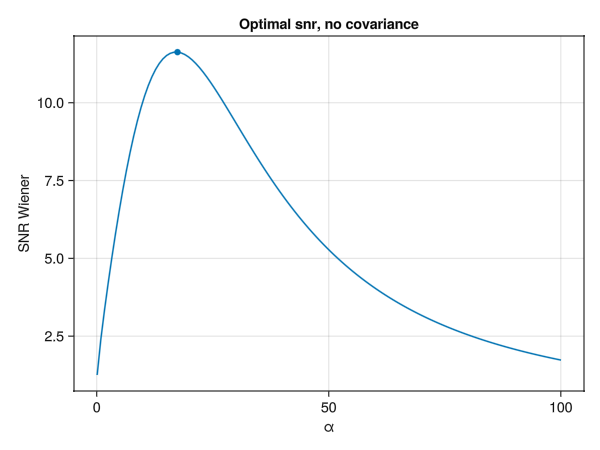

In [3]:
# optimize α no noise covariance

function wiener(dirty, psf, α)
    fpsf = fft(ifftshift(psf))
    isa(α, Number) && (α = α*ones(size(psf)))
    W = conj(fpsf)./(abs2.(fpsf) + α)
    real.(ifft(W.*fft(dirty)))
end

function crop_img(x, size_mask) 
    (l,n) = size(x)
    x[size_mask+1:l-size_mask, size_mask+1:n-size_mask]
end

comp_snr(x̂, x, size_mask) =  sum(crop_img(x̂, size_mask).^2)/sum(crop_img(x - x̂, size_mask).^2)

# optimize snr no cov

size_mask = 50
#mask = comp_mask(sky, 30) 
α_pl = LinRange(1e-1, 1e2, 128)
snrs = Float64[]
for α in α_pl
    deconv_nocov = wiener(dirty_low, psf, α)
    push!(snrs, comp_snr(deconv_nocov, sky, size_mask)) 
end

snr_nocov, ind = findmax(snrs)
α_nocov = α_pl[ind]

println("-> snr with cov: snr=$snr_nocov, α = $α_nocov")


fig = Figure()
ax1 = Axis(fig[1, 1], title  = "Optimal snr, no covariance", ylabel = "SNR Wiener", xlabel="α")
lines!(α_pl, snrs)
scatter!([α_nocov], [snr_nocov])
fig

-> snr with cov: snr=2.9254381281776447, α = 3.636220472440945


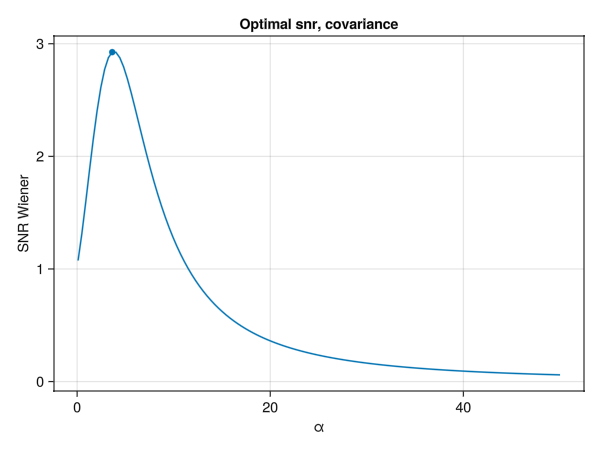

In [4]:
# optimize snr with noise covariance

fpsf = abs.(fft(ifftshift(psf)))
#mask = comp_mask(sky, 30) 
α_pl = LinRange(1e-1, 5e1, 128)
snrs = Float64[]

for α in α_pl
    deconv_cov = wiener(dirty_low, psf, α*fpsf)
    push!(snrs, comp_snr(deconv_cov, sky, size_mask)) 
end

snr_cov, ind = findmax(snrs)
α_cov = α_pl[ind]

println("-> snr with cov: snr=$snr_cov, α = $α_cov")

fig = Figure()
ax1 = Axis(fig[1, 1], title  = "Optimal snr, covariance", ylabel = "SNR Wiener", xlabel="α")
lines!(α_pl, snrs)
scatter!([α_cov], [snr_cov])
fig

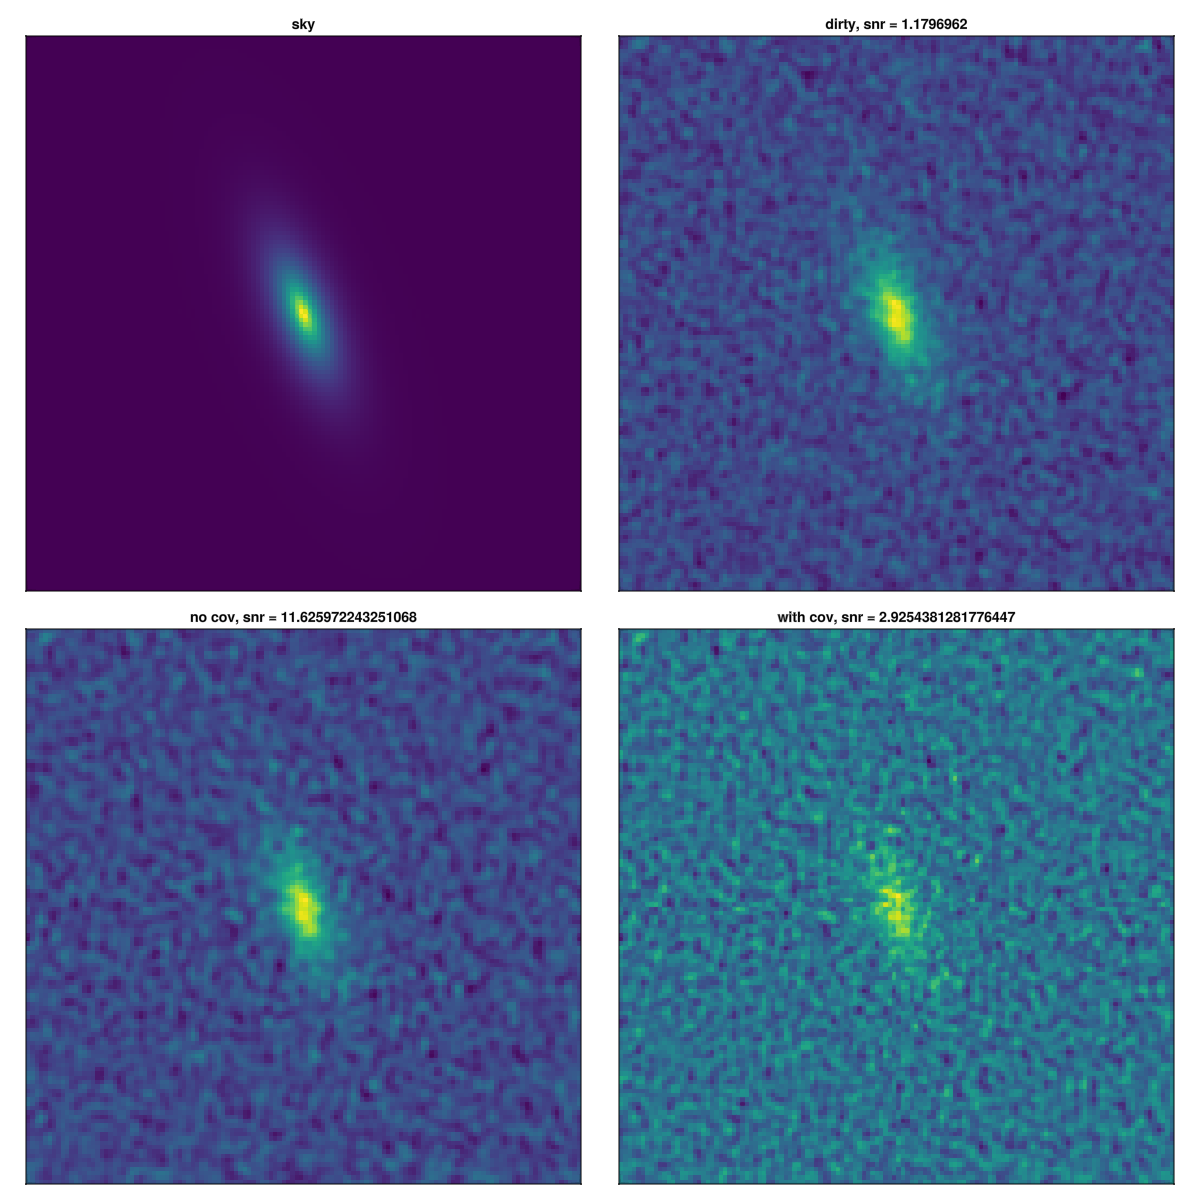

In [5]:
deconv_nocov = wiener(dirty_low, psf, α_nocov)
deconv_cov = wiener(dirty_low, psf, α_cov*fpsf)
snr_dirty = comp_snr(dirty_low, sky, size_mask)

fig = Figure(; size = (1200, 1200))
ax1 = Axis(fig[1, 1], title="sky", aspect=DataAspect())
ax2 = Axis(fig[1, 2], title="dirty, snr = $snr_dirty", aspect=DataAspect())
ax3 = Axis(fig[2, 1], title="no cov, snr = $snr_nocov", aspect=DataAspect())
ax4 = Axis(fig[2, 2], title="with cov, snr = $snr_cov", aspect=DataAspect())
heatmap!(ax1, sky)
heatmap!(ax2, dirty_low)
heatmap!(ax3, deconv_nocov)
heatmap!(ax4, deconv_cov)

hidedecorations!(ax1)
hidedecorations!(ax2)
hidedecorations!(ax3)
hidedecorations!(ax4)
fig

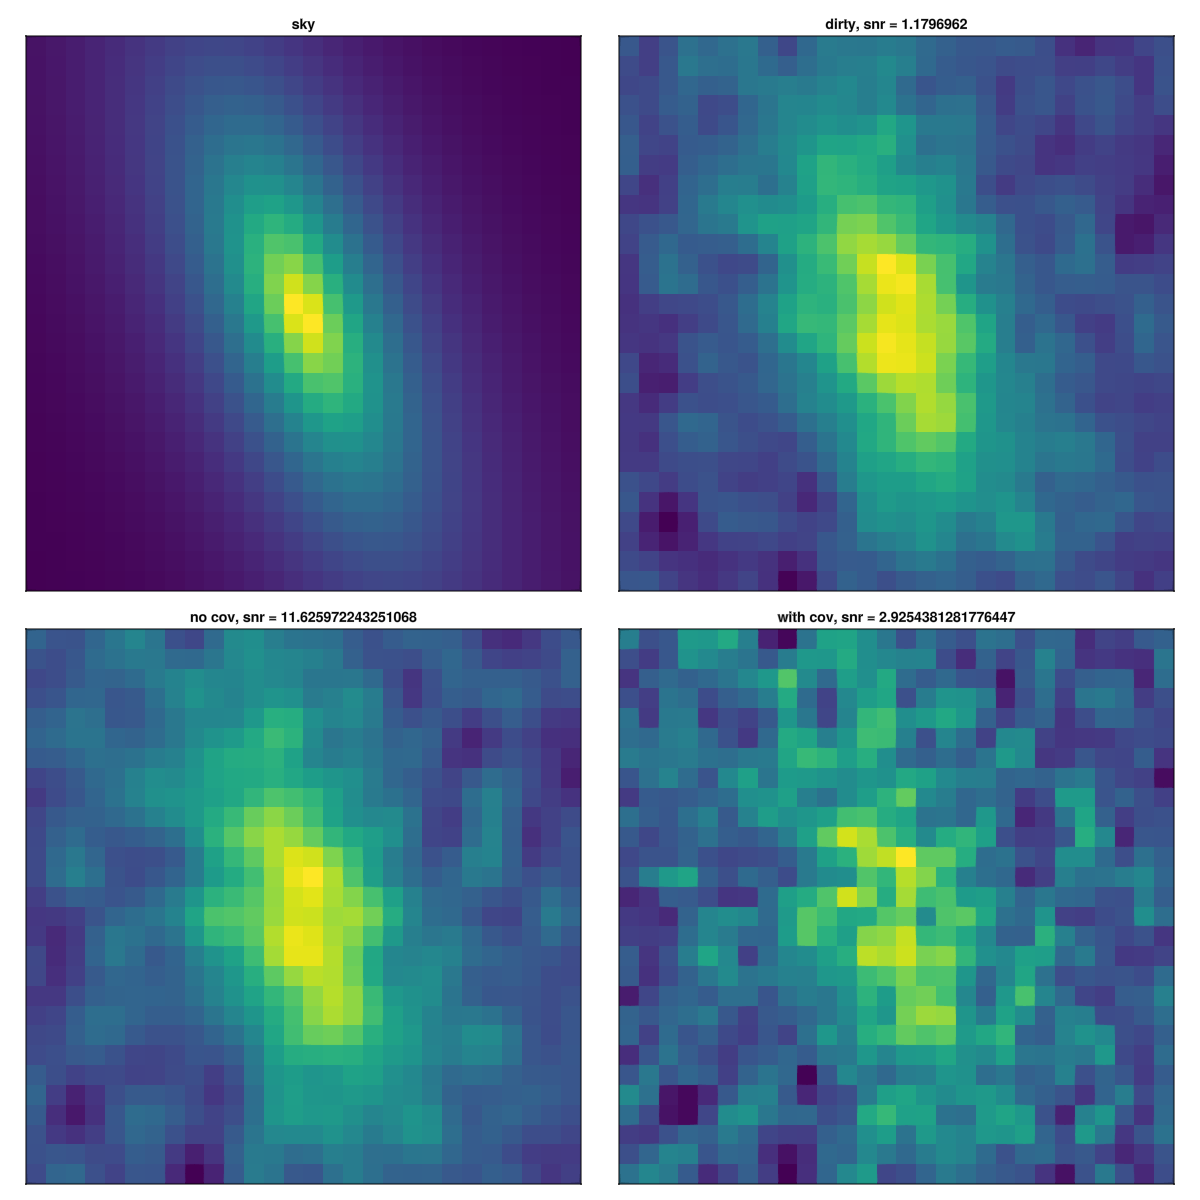

In [6]:
deconv_nocov = wiener(dirty_low, psf, α_nocov)
deconv_cov = wiener(dirty_low, psf, α_cov*fpsf)
snr_dirty = comp_snr(dirty_low, sky, size_mask)

fig = Figure(; size = (1200, 1200))
ax1 = Axis(fig[1, 1], title="sky", aspect=DataAspect())
ax2 = Axis(fig[1, 2], title="dirty, snr = $snr_dirty", aspect=DataAspect())
ax3 = Axis(fig[2, 1], title="no cov, snr = $snr_nocov", aspect=DataAspect())
ax4 = Axis(fig[2, 2], title="with cov, snr = $snr_cov", aspect=DataAspect())

size_mask = 50
heatmap!(ax1, crop_img(sky, size_mask))
heatmap!(ax2, crop_img(dirty_low, size_mask))
heatmap!(ax3, crop_img(deconv_nocov, size_mask))
heatmap!(ax4, crop_img(deconv_cov, size_mask))

hidedecorations!(ax1)
hidedecorations!(ax2)
hidedecorations!(ax3)
hidedecorations!(ax4)
fig

## For FISTA

In [7]:
using DeconvMultiStep
using LinearAlgebra

function imfilter(img::Matrix{T}, psf::Matrix{T}) where {T<:Real}
    @assert size(img) == size(psf) "Image and psf must have the same size"
    real(ifft(fft(img).*fft(ifftshift(psf))))
end

psf = reshape(psf, (128, 128))
sky = reshape(sky, (128, 128))
dirty_low = reshape(dirty_low, (128, 128))
dirty_high = reshape(dirty_high, (128, 128))

128×128 Matrix{Float32}:
  9.41807f-7   1.09589f-6   1.05694f-6  …  -4.00288f-7  -8.80542f-7
  1.29404f-6   1.87116f-6   8.37999f-7      2.06088f-6   7.80422f-7
  9.00564f-7   1.6351f-6    1.26588f-6      1.35565f-6   8.41151f-7
 -5.51239f-7   4.655f-7     7.42427f-7     -8.09643f-7  -6.12512f-7
  4.13738f-7   1.17073f-7  -1.01708f-6     -6.27407f-7  -9.08706f-7
  1.02912f-6   9.56986f-7  -1.93263f-7  …   4.46931f-7   2.93337f-7
 -2.81884f-7   3.79604f-7   3.79909f-7      1.22693f-6   1.28729f-6
  1.3061f-7    4.63161f-8   4.49383f-7      2.43409f-6   1.85165f-6
  1.64454f-6   1.47092f-6   1.93373f-6      1.6381f-6    8.66963f-7
  1.59073f-6   9.77768f-7   1.18989f-6     -1.75027f-7  -6.25176f-7
 -2.63277f-7  -1.04541f-6  -1.13615f-6  …  -2.40951f-7  -7.82186f-7
 -4.24635f-8  -1.44939f-6  -1.91055f-6     -1.31748f-6  -1.55654f-6
  1.12702f-6   1.49534f-7  -4.08505f-7     -2.18474f-6  -1.95932f-6
  ⋮                                     ⋱               
  5.39474f-7   5.20849f-7   1.6227

### First without variance taken into account

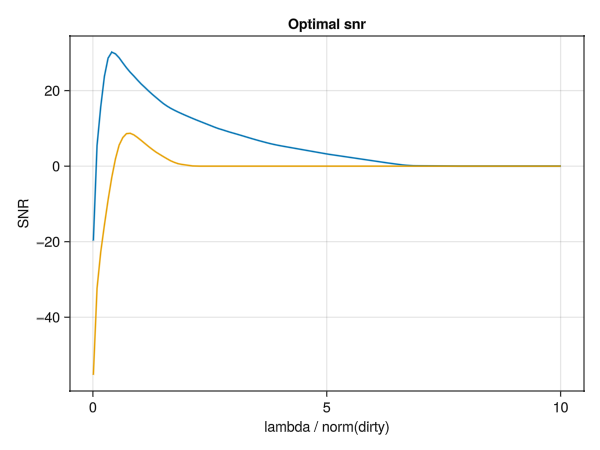

In [8]:
lambdas = LinRange(1e-2, 10, 128)

snrs_low = Float64[]
snrs_high = Float64[]
for lambda in lambdas
    deconv, dist, mse, costs = fista(Float64.(psf), Float64.(dirty_low), lambda * norm(dirty_low), 50; sky=Float64.(sky))
    snr = 20 * log(norm(sky) / sqrt(mse[end]))
    push!(snrs_low, snr) 
end
for lambda in lambdas
    deconv, dist, mse, costs = fista(Float64.(psf), Float64.(dirty_high), lambda * norm(dirty_high), 50; sky=Float64.(sky))
    snr = 20 * log(norm(sky) / sqrt(mse[end]))
    push!(snrs_high, snr) 
end

fig = Figure()
ax1 = Axis(fig[1, 1], title  = "Optimal snr", ylabel = "SNR", xlabel="lambda / norm(dirty)")
lines!(lambdas, snrs_low)
lines!(lambdas, snrs_high)
#scatter!([α_cov], [snr_cov])
fig

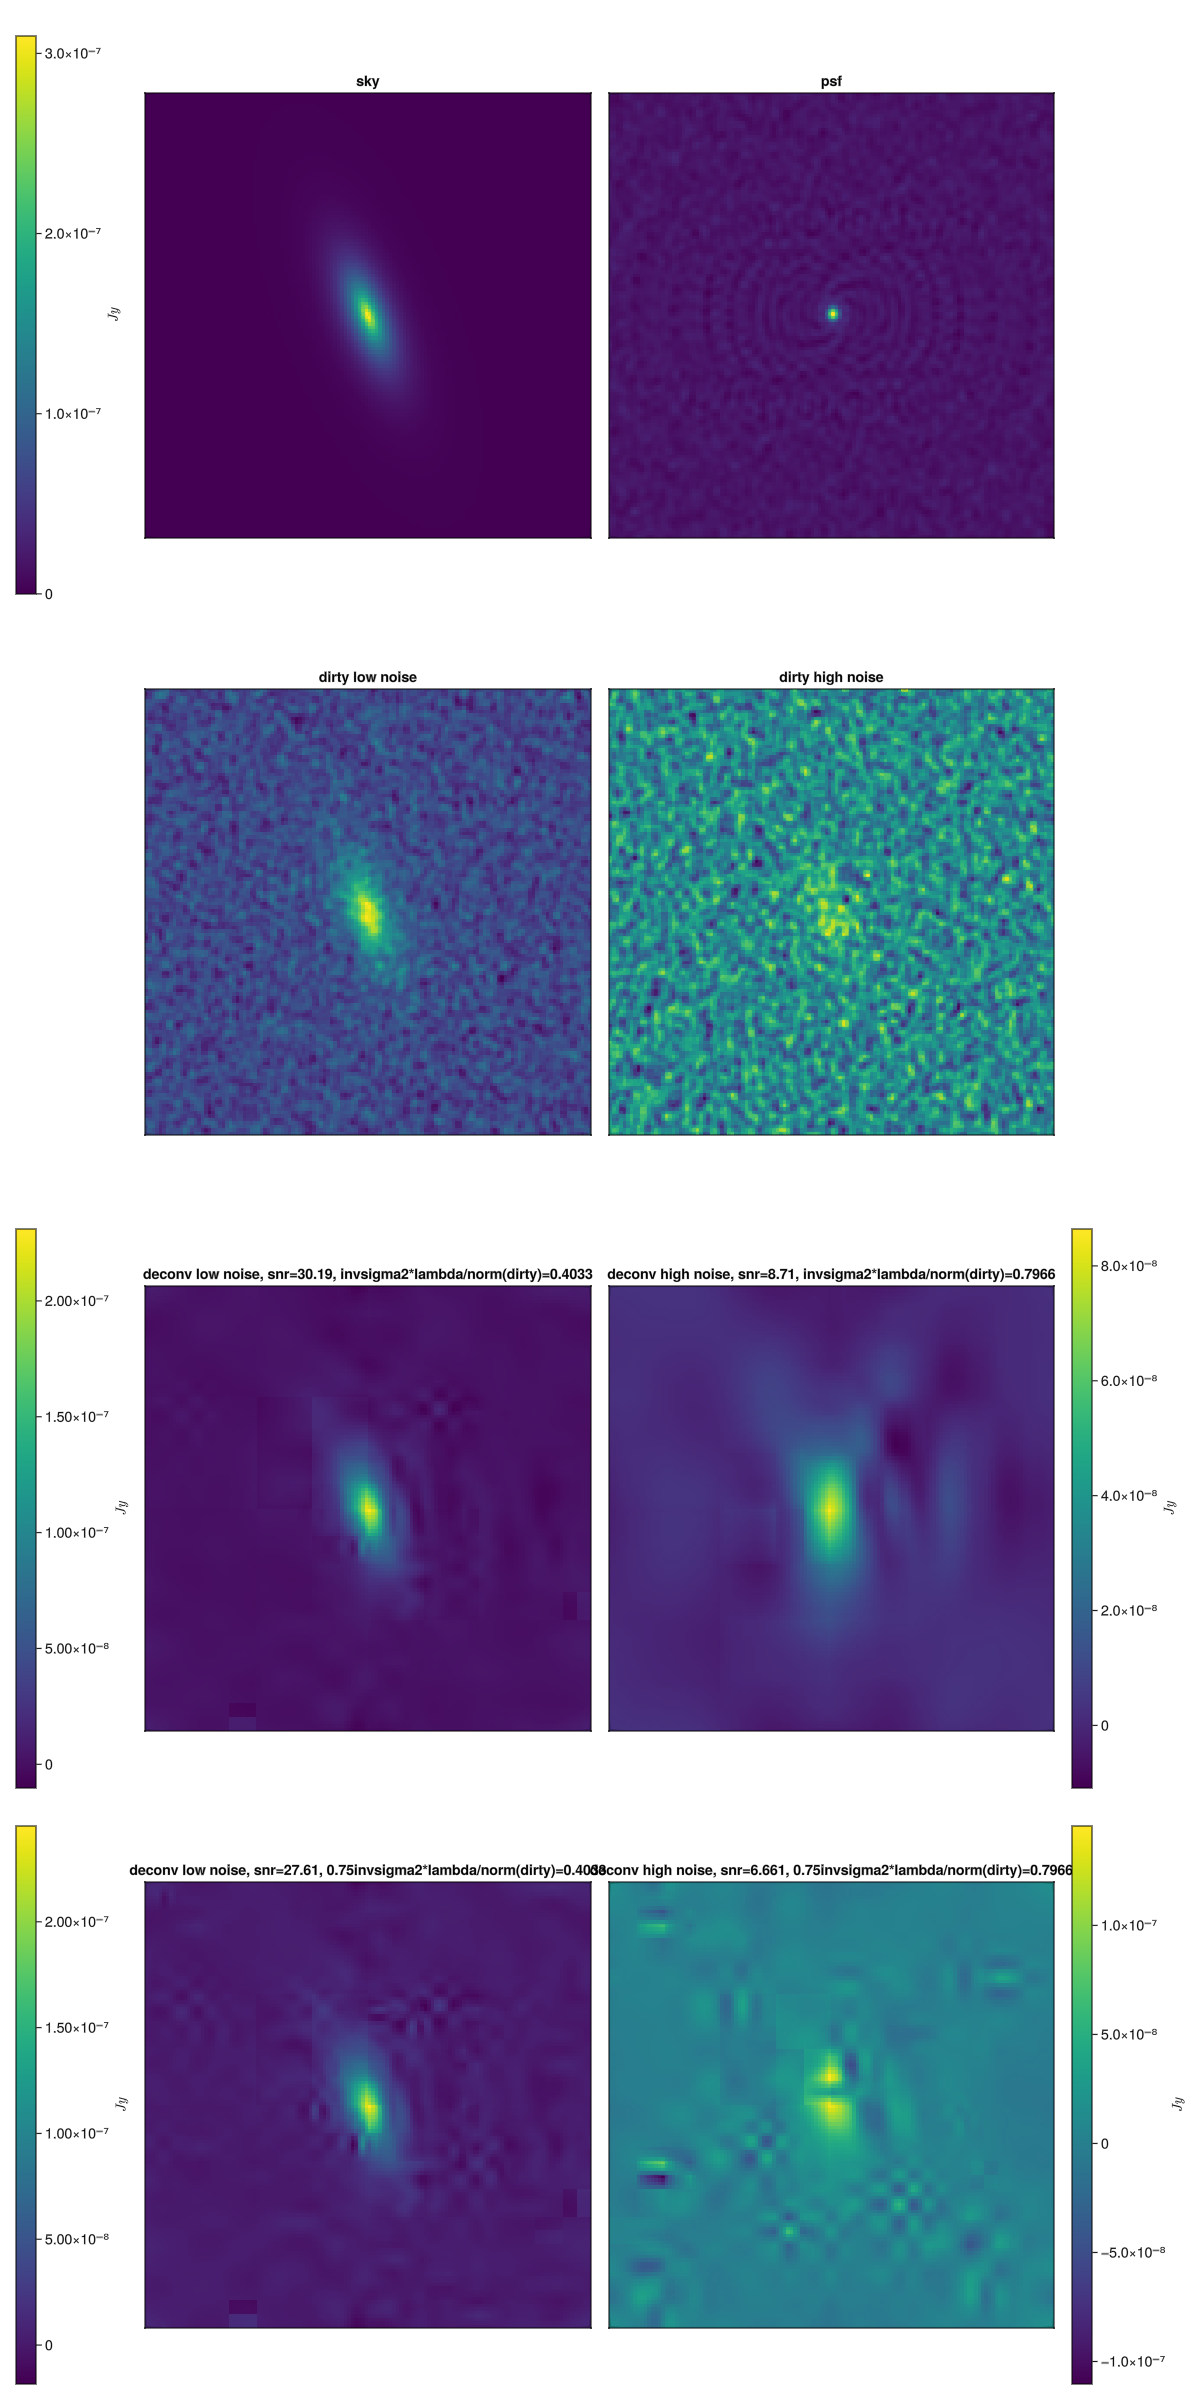

In [9]:
snr_low, ind_low = findmax(snrs_low)
snr_high, ind_high = findmax(snrs_high)

low_lambda = lambdas[ind_low] * norm(dirty_low)
high_lambda = lambdas[ind_high] * norm(dirty_high)

deconv_low, dist, mse, costs = fista(Float64.(psf), Float64.(dirty_low), low_lambda, 50; sky=Float64.(sky))
deconv_high, dist, mse, costs = fista(Float64.(psf), Float64.(dirty_low), high_lambda, 50; sky=Float64.(sky))
        
deconv_low_ll, dist, mse, costs = fista(Float64.(psf), Float64.(dirty_low), 0.75*low_lambda, 50; sky=Float64.(sky))
snr_low_ll = 20 * log(norm(sky) / sqrt(mse[end]))
deconv_high_ll, dist, mse, costs = fista(Float64.(psf), Float64.(dirty_high), 0.75*high_lambda, 50; sky=Float64.(sky))
snr_high_ll = 20 * log(norm(sky) / sqrt(mse[end]))

fig = Figure(; size = (1200, 2400))
ax1 = Axis(fig[1, 1], title="sky", aspect=DataAspect())
ax2 = Axis(fig[1, 2], title="psf", aspect=DataAspect())
ax3 = Axis(fig[2, 1], title="dirty low noise", aspect=DataAspect())
ax4 = Axis(fig[2, 2], title="dirty high noise", aspect=DataAspect())

llow = lambdas[ind_low]
lhigh = lambdas[ind_high]

ax5 = Axis(fig[3, 1], title="deconv low noise, snr=$(round(snr_low, sigdigits=4)), invsigma2*lambda/norm(dirty)=$(round(llow, sigdigits=4))", aspect=DataAspect())
ax6 = Axis(fig[3, 2], title="deconv high noise, snr=$(round(snr_high, sigdigits=4)), invsigma2*lambda/norm(dirty)=$(round(lhigh, sigdigits=4))", aspect=DataAspect())

ax7 = Axis(fig[4, 1], title="deconv low noise, snr=$(round(snr_low_ll, sigdigits=4)), 0.75invsigma2*lambda/norm(dirty)=$(round(llow, sigdigits=4))", aspect=DataAspect())
ax8 = Axis(fig[4, 2], title="deconv high noise, snr=$(round(snr_high_ll, sigdigits=4)), 0.75invsigma2*lambda/norm(dirty)=$(round(lhigh, sigdigits=4))", aspect=DataAspect())                        

size_mask = 0
hm = heatmap!(ax1, sky)
Colorbar(fig[1, 0], hm, label = L"Jy", width = 20, labelsize = 14, ticklabelsize = 14)
heatmap!(ax2, psf)
heatmap!(ax3, dirty_low)
heatmap!(ax4, dirty_high)
hm2 = heatmap!(ax5, deconv_low)
Colorbar(fig[3, 0], hm2, label = L"Jy", width = 20, labelsize = 14, ticklabelsize = 14)
hm3 = heatmap!(ax6, deconv_high)
Colorbar(fig[3, 3], hm3, label = L"Jy", width = 20, labelsize = 14, ticklabelsize = 14)
hm4 = heatmap!(ax7, deconv_low_ll)
Colorbar(fig[4, 0], hm4, label = L"Jy", width = 20, labelsize = 14, ticklabelsize = 14)
hm5 = heatmap!(ax8, deconv_high_ll)
Colorbar(fig[4, 3], hm5, label = L"Jy", width = 20, labelsize = 14, ticklabelsize = 14)

hidedecorations!(ax1)
hidedecorations!(ax2)
hidedecorations!(ax3)
hidedecorations!(ax4)
hidedecorations!(ax5)
hidedecorations!(ax6)
hidedecorations!(ax7)
hidedecorations!(ax8)
fig

### Now assuming some i.i.d Gaussian noise in the gridded visibility domain, i.e. $\sigma^2 H$ in the image domain
### With $H = F^\dagger \Delta F$ and $\Sigma = \sigma^2 I$, we have a gradient of $W^\dagger F^\dagger \Delta^\dagger \Delta^\# \Sigma^{-1}(\Delta F W\alpha - F\tilde{\imath})$  where $\dagger$ denotes conjugate transpose and $\#$ denotes pseudo-inverse.

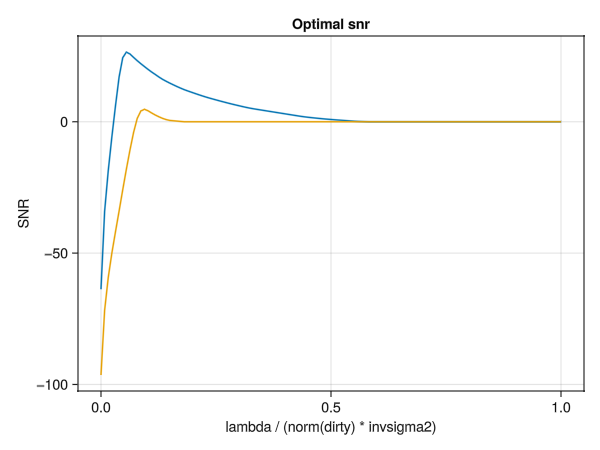

In [10]:
using FFTW

lambdas = LinRange(1e-5, 1, 128)

invsigma2 = 1 / 1e-3

fpsf = fft(ifftshift(psf))
finvvar = convert(Matrix{ComplexF64}, [real(x) > 1e-4 ? invsigma2 : 0 for x in fpsf])
invvar = real.(fftshift(ifft(finvvar)))
fixed_psf = real.(fftshift(ifft(real.(fpsf))))

snrs_low = Float64[]
snrs_high = Float64[]
for lambda in lambdas
    deconv, mse = fista_cov(Float64.(fixed_psf), Float64.(dirty_low), Float64.(invvar), invsigma2 * lambda * norm(dirty_low), 50; sky=Float64.(sky))
    snr = 20 * log(norm(sky) / sqrt(mse[end]))
    push!(snrs_low, snr) 
end
for lambda in lambdas
    deconv, mse = fista_cov(Float64.(fixed_psf), Float64.(dirty_high), Float64.(invvar), invsigma2 * lambda * norm(dirty_high), 50; sky=Float64.(sky))
    snr = 20 * log(norm(sky) / sqrt(mse[end]))
    push!(snrs_high, snr) 
end

fig = Figure()
ax1 = Axis(fig[1, 1], title  = "Optimal snr", ylabel = "SNR", xlabel="lambda / (norm(dirty) * invsigma2)")
lines!(lambdas, snrs_low)
lines!(lambdas, snrs_high)
#scatter!([α_cov], [snr_cov])
fig


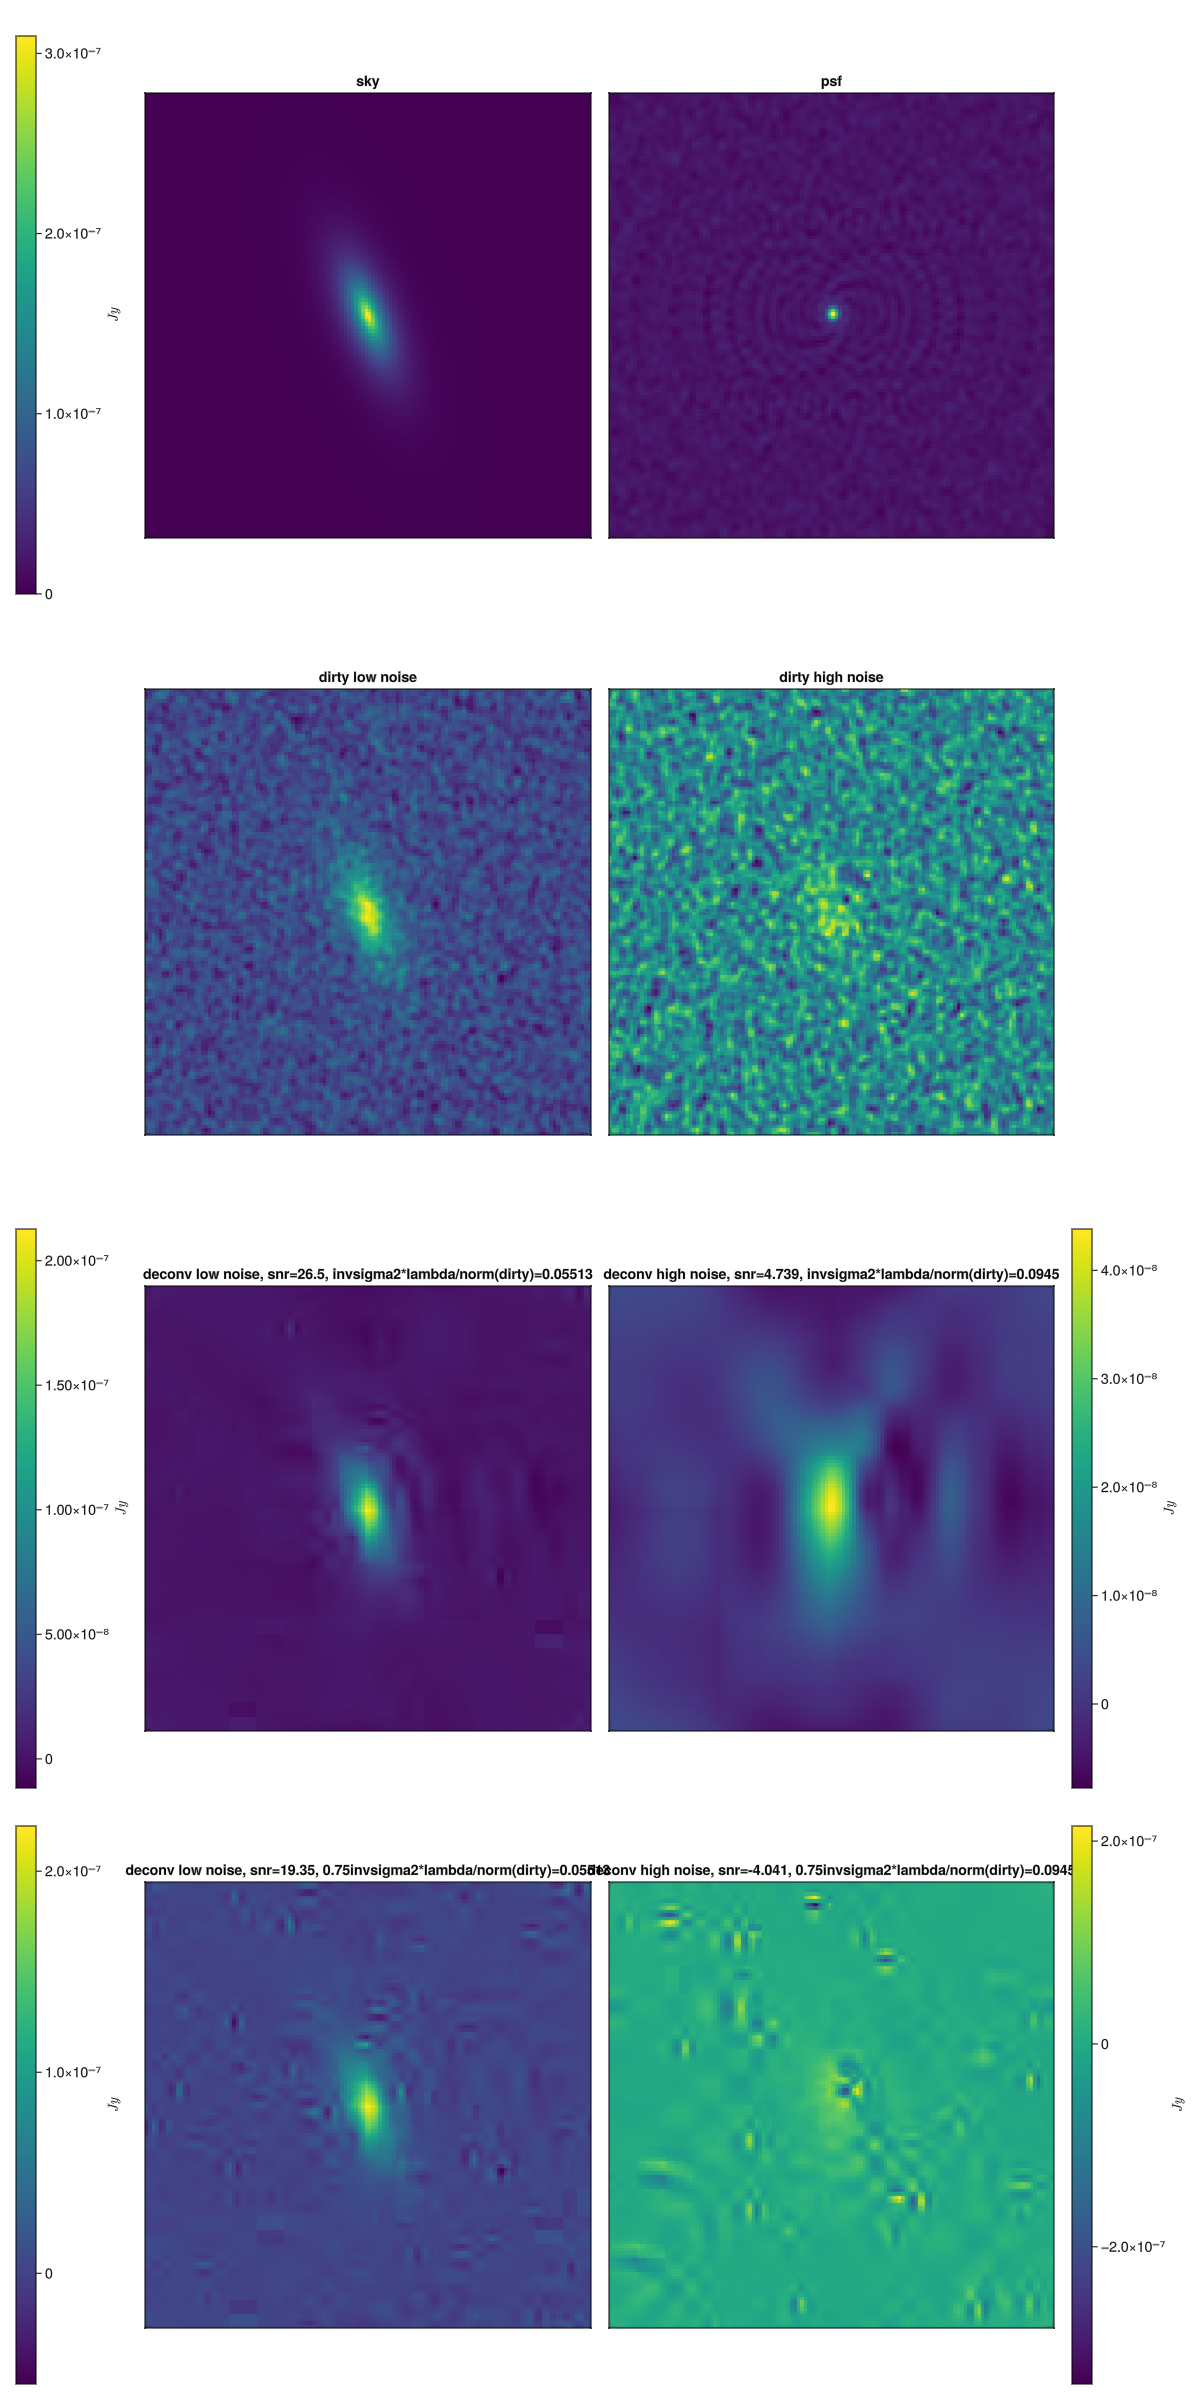

In [11]:
snr_low, ind_low = findmax(snrs_low)
snr_high, ind_high = findmax(snrs_high)

low_lambda = invsigma2 * lambdas[ind_low] * norm(dirty_low)
high_lambda = invsigma2 * lambdas[ind_high] * norm(dirty_high)

deconv_low, mse = fista_cov(Float64.(fixed_psf), Float64.(dirty_low), Float64.(invvar), low_lambda, 50; sky=Float64.(sky))
deconv_high, mse = fista_cov(Float64.(fixed_psf), Float64.(dirty_low), Float64.(invvar), high_lambda, 50; sky=Float64.(sky))

deconv_low_ll, mse = fista_cov(Float64.(fixed_psf), Float64.(dirty_low), Float64.(invvar), 0.75 * low_lambda, 50; sky=Float64.(sky))
snr_low_ll = 20 * log(norm(sky) / sqrt(mse[end]))
deconv_high_ll, mse = fista_cov(Float64.(fixed_psf), Float64.(dirty_high), Float64.(invvar), 0.75 * high_lambda, 50; sky=Float64.(sky))
snr_high_ll = 20 * log(norm(sky) / sqrt(mse[end]))
                    
fig = Figure(; size = (1200, 2400))
ax1 = Axis(fig[1, 1], title="sky", aspect=DataAspect())
ax2 = Axis(fig[1, 2], title="psf", aspect=DataAspect())
ax3 = Axis(fig[2, 1], title="dirty low noise", aspect=DataAspect())
ax4 = Axis(fig[2, 2], title="dirty high noise", aspect=DataAspect())

llow = lambdas[ind_low]
lhigh = lambdas[ind_high]

ax5 = Axis(fig[3, 1], title="deconv low noise, snr=$(round(snr_low, sigdigits=4)), invsigma2*lambda/norm(dirty)=$(round(llow, sigdigits=4))", aspect=DataAspect())
ax6 = Axis(fig[3, 2], title="deconv high noise, snr=$(round(snr_high, sigdigits=4)), invsigma2*lambda/norm(dirty)=$(round(lhigh, sigdigits=4))", aspect=DataAspect())

ax7 = Axis(fig[4, 1], title="deconv low noise, snr=$(round(snr_low_ll, sigdigits=4)), 0.75invsigma2*lambda/norm(dirty)=$(round(llow, sigdigits=4))", aspect=DataAspect())
ax8 = Axis(fig[4, 2], title="deconv high noise, snr=$(round(snr_high_ll, sigdigits=4)), 0.75invsigma2*lambda/norm(dirty)=$(round(lhigh, sigdigits=4))", aspect=DataAspect())                        

size_mask = 0
hm = heatmap!(ax1, sky)
Colorbar(fig[1, 0], hm, label = L"Jy", width = 20, labelsize = 14, ticklabelsize = 14)
heatmap!(ax2, psf)
heatmap!(ax3, dirty_low)
heatmap!(ax4, dirty_high)
hm2 = heatmap!(ax5, deconv_low)
Colorbar(fig[3, 0], hm2, label = L"Jy", width = 20, labelsize = 14, ticklabelsize = 14)
hm3 = heatmap!(ax6, deconv_high)
Colorbar(fig[3, 3], hm3, label = L"Jy", width = 20, labelsize = 14, ticklabelsize = 14)
hm4 = heatmap!(ax7, deconv_low_ll)
Colorbar(fig[4, 0], hm4, label = L"Jy", width = 20, labelsize = 14, ticklabelsize = 14)
hm5 = heatmap!(ax8, deconv_high_ll)
Colorbar(fig[4, 3], hm5, label = L"Jy", width = 20, labelsize = 14, ticklabelsize = 14)

hidedecorations!(ax1)
hidedecorations!(ax2)
hidedecorations!(ax3)
hidedecorations!(ax4)
hidedecorations!(ax5)
hidedecorations!(ax6)
hidedecorations!(ax7)
hidedecorations!(ax8)
fig

### Now assuming some i.i.d Gaussian noise in the image domain, i.e. $\sigma^2 I$
### The gradient becomes $W^\dagger F^\dagger \Delta^\dagger \Sigma^{-1}(\Delta F W\alpha - F\tilde{\imath})$

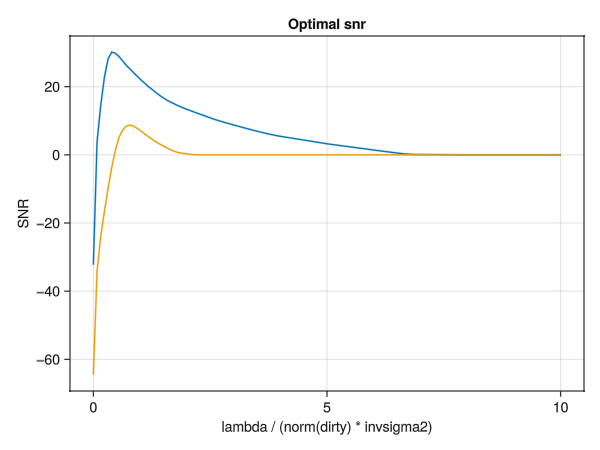

In [12]:
using FFTW

lambdas = LinRange(1e-4, 10, 128)

invsigma2 = 1 / 1e-3

fpsf = fft(ifftshift(psf))
fixed_psf = real.(fftshift(ifft(real.(fpsf))))
invvar = fixed_psf * invsigma2

snrs_low = Float64[]
snrs_high = Float64[]
for lambda in lambdas
    deconv, mse = fista_cov(Float64.(fixed_psf), Float64.(dirty_low), Float64.(invvar), invsigma2 * lambda * norm(dirty_low), 50; sky=Float64.(sky))
    snr = 20 * log(norm(sky) / sqrt(mse[end]))
    push!(snrs_low, snr) 
end
for lambda in lambdas
    deconv, mse = fista_cov(Float64.(fixed_psf), Float64.(dirty_high), Float64.(invvar), invsigma2 * lambda * norm(dirty_high), 50; sky=Float64.(sky))
    snr = 20 * log(norm(sky) / sqrt(mse[end]))
    push!(snrs_high, snr) 
end

fig = Figure()
ax1 = Axis(fig[1, 1], title  = "Optimal snr", ylabel = "SNR", xlabel="lambda / (norm(dirty) * invsigma2)")
lines!(lambdas, snrs_low)
lines!(lambdas, snrs_high)
#scatter!([α_cov], [snr_cov])
fig


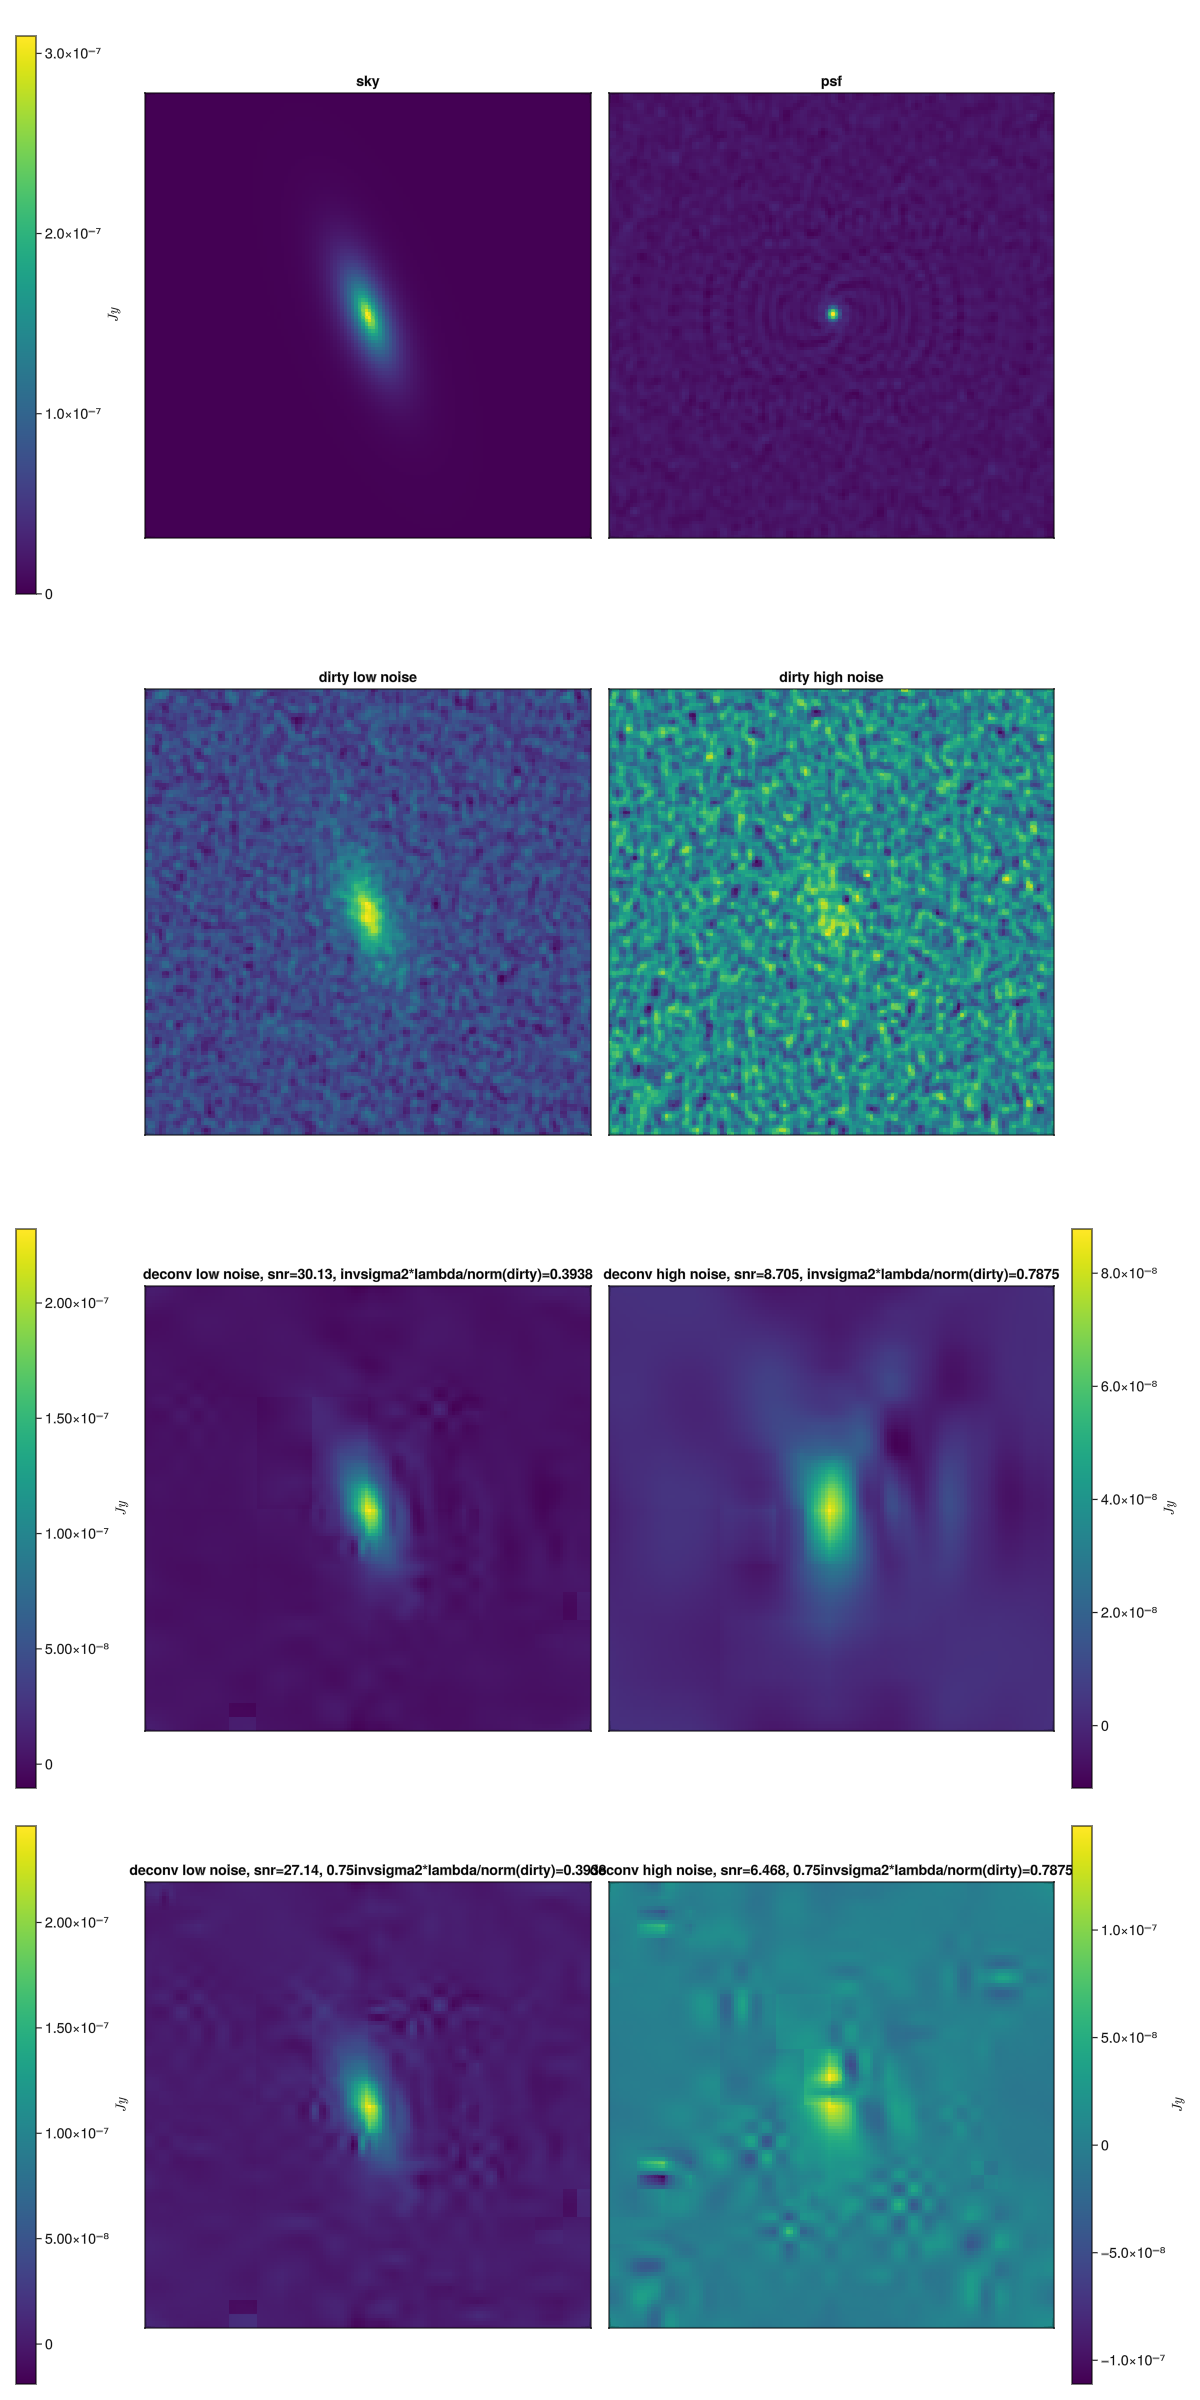

In [13]:
snr_low, ind_low = findmax(snrs_low)
snr_high, ind_high = findmax(snrs_high)

low_lambda = invsigma2 * lambdas[ind_low] * norm(dirty_low)
high_lambda = invsigma2 * lambdas[ind_high] * norm(dirty_high)

deconv_low, mse = fista_cov(Float64.(fixed_psf), Float64.(dirty_low), Float64.(invvar), low_lambda, 50; sky=Float64.(sky))
deconv_high, mse = fista_cov(Float64.(fixed_psf), Float64.(dirty_low), Float64.(invvar), high_lambda, 50; sky=Float64.(sky))

deconv_low_ll, mse = fista_cov(Float64.(fixed_psf), Float64.(dirty_low), Float64.(invvar), 0.75 * low_lambda, 50; sky=Float64.(sky))
snr_low_ll = 20 * log(norm(sky) / sqrt(mse[end]))
deconv_high_ll, mse = fista_cov(Float64.(fixed_psf), Float64.(dirty_high), Float64.(invvar), 0.75 * high_lambda, 50; sky=Float64.(sky))
snr_high_ll = 20 * log(norm(sky) / sqrt(mse[end]))
                    
fig = Figure(; size = (1200, 2400))
ax1 = Axis(fig[1, 1], title="sky", aspect=DataAspect())
ax2 = Axis(fig[1, 2], title="psf", aspect=DataAspect())
ax3 = Axis(fig[2, 1], title="dirty low noise", aspect=DataAspect())
ax4 = Axis(fig[2, 2], title="dirty high noise", aspect=DataAspect())

llow = lambdas[ind_low]
lhigh = lambdas[ind_high]

ax5 = Axis(fig[3, 1], title="deconv low noise, snr=$(round(snr_low, sigdigits=4)), invsigma2*lambda/norm(dirty)=$(round(llow, sigdigits=4))", aspect=DataAspect())
ax6 = Axis(fig[3, 2], title="deconv high noise, snr=$(round(snr_high, sigdigits=4)), invsigma2*lambda/norm(dirty)=$(round(lhigh, sigdigits=4))", aspect=DataAspect())

ax7 = Axis(fig[4, 1], title="deconv low noise, snr=$(round(snr_low_ll, sigdigits=4)), 0.75invsigma2*lambda/norm(dirty)=$(round(llow, sigdigits=4))", aspect=DataAspect())
ax8 = Axis(fig[4, 2], title="deconv high noise, snr=$(round(snr_high_ll, sigdigits=4)), 0.75invsigma2*lambda/norm(dirty)=$(round(lhigh, sigdigits=4))", aspect=DataAspect())                        

size_mask = 0
hm = heatmap!(ax1, sky)
Colorbar(fig[1, 0], hm, label = L"Jy", width = 20, labelsize = 14, ticklabelsize = 14)
heatmap!(ax2, psf)
heatmap!(ax3, dirty_low)
heatmap!(ax4, dirty_high)
hm2 = heatmap!(ax5, deconv_low)
Colorbar(fig[3, 0], hm2, label = L"Jy", width = 20, labelsize = 14, ticklabelsize = 14)
hm3 = heatmap!(ax6, deconv_high)
Colorbar(fig[3, 3], hm3, label = L"Jy", width = 20, labelsize = 14, ticklabelsize = 14)
hm4 = heatmap!(ax7, deconv_low_ll)
Colorbar(fig[4, 0], hm4, label = L"Jy", width = 20, labelsize = 14, ticklabelsize = 14)
hm5 = heatmap!(ax8, deconv_high_ll)
Colorbar(fig[4, 3], hm5, label = L"Jy", width = 20, labelsize = 14, ticklabelsize = 14)

hidedecorations!(ax1)
hidedecorations!(ax2)
hidedecorations!(ax3)
hidedecorations!(ax4)
hidedecorations!(ax5)
hidedecorations!(ax6)
hidedecorations!(ax7)
hidedecorations!(ax8)
fig